In [5]:
import pandas as pd
import numpy as np
final_data = pd.read_csv('final.csv')

In [7]:
final_features = ['inning', 'cum_runs', 'cum_wickets', 'current_run_rate', 
                  'required_run_rate', 'target', 
                  'batting_team_encoded', 'bowling_team_encoded', 'venue_canonical_encoded', 'win']

final_data = final_data[final_features]

In [9]:
from sklearn.model_selection import train_test_split

X = final_data.drop(columns=["win"])
y = final_data["win"]  # Target variable (1 if batting_team won, 0 otherwise)

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print dataset shapes
print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set: X_test={X_test.shape}, y_test={y_test.shape}")

Training set: X_train=(100592, 9), y_train=(100592,)
Test set: X_test=(25149, 9), y_test=(25149,)



==== Logistic Regression ====

Training Metrics:
Accuracy: 78.1523
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.75      0.77     48316
           1       0.78      0.81      0.79     52276

    accuracy                           0.78    100592
   macro avg       0.78      0.78      0.78    100592
weighted avg       0.78      0.78      0.78    100592



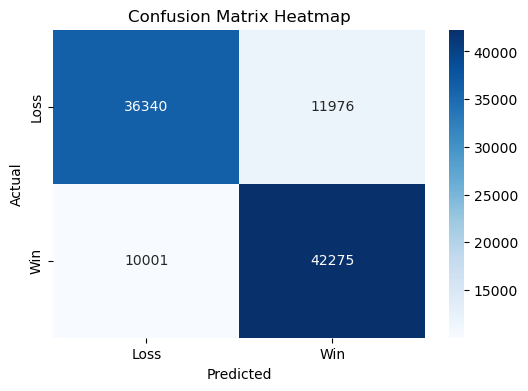


Testing Metrics:
Accuracy: 77.7287
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.74      0.76     12079
           1       0.77      0.81      0.79     13070

    accuracy                           0.78     25149
   macro avg       0.78      0.78      0.78     25149
weighted avg       0.78      0.78      0.78     25149



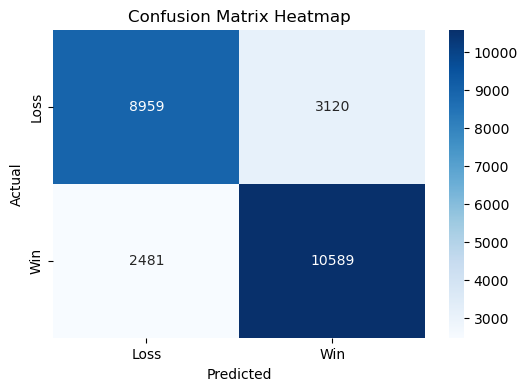


==== Random Forest ====

Training Metrics:
Accuracy: 99.9950
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     48316
           1       1.00      1.00      1.00     52276

    accuracy                           1.00    100592
   macro avg       1.00      1.00      1.00    100592
weighted avg       1.00      1.00      1.00    100592



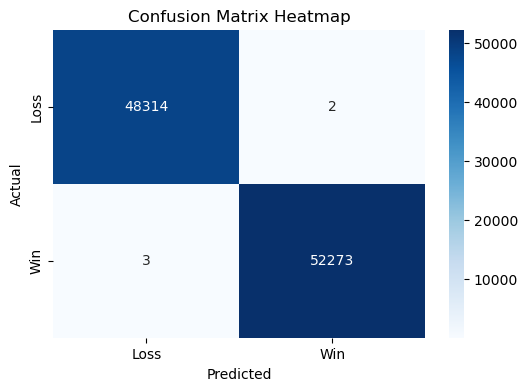


Testing Metrics:
Accuracy: 99.7256
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     12079
           1       1.00      1.00      1.00     13070

    accuracy                           1.00     25149
   macro avg       1.00      1.00      1.00     25149
weighted avg       1.00      1.00      1.00     25149



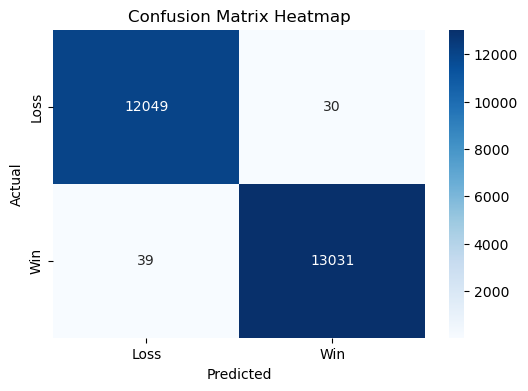


==== XGBoost ====


C:\Users\vegu2\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:35:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Training Metrics:
Accuracy: 99.6938
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     48316
           1       1.00      1.00      1.00     52276

    accuracy                           1.00    100592
   macro avg       1.00      1.00      1.00    100592
weighted avg       1.00      1.00      1.00    100592



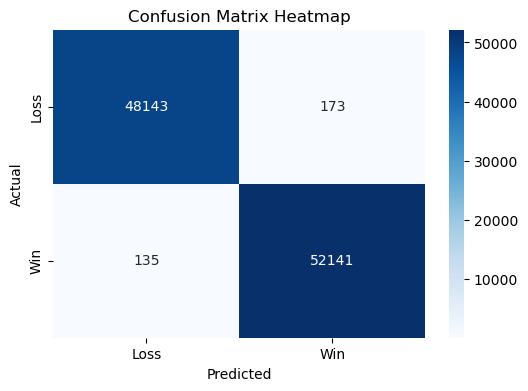


Testing Metrics:
Accuracy: 99.6024
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     12079
           1       1.00      1.00      1.00     13070

    accuracy                           1.00     25149
   macro avg       1.00      1.00      1.00     25149
weighted avg       1.00      1.00      1.00     25149



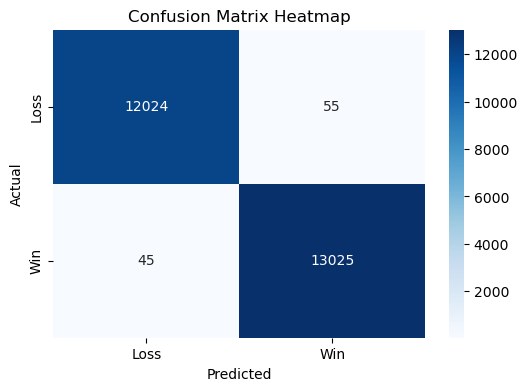

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver="liblinear"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Train models and evaluate
for model_name, model in models.items():
    print(f"\n==== {model_name} ====")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    cm = confusion_matrix(y_train,y_train_pred)
    cmt = confusion_matrix(y_test,y_test_pred)
    
    # Metrics
    print("\nTraining Metrics:")
    print(f"Accuracy: {accuracy_score(y_train, y_train_pred) * 100:.4f}")
    print("Classification Report:\n", classification_report(y_train, y_train_pred))
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss', 'Win'], yticklabels=['Loss', 'Win'])

# Labels & Title
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix Heatmap')
    plt.show()
    
    print("\nTesting Metrics:")
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred) * 100:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_test_pred))
    plt.figure(figsize=(6, 4))
    sns.heatmap(cmt, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss', 'Win'], yticklabels=['Loss', 'Win'])

# Labels & Title
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix Heatmap')
    plt.show()

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np

# ---------------------------
# Hyperparameter Tuning for Logistic Regression
# ---------------------------
lr = LogisticRegression(max_iter=1000, random_state=42)
param_dist_lr = {
    'C': [0.01, 0.1, 1, 10, 100]
}

rand_search_lr = RandomizedSearchCV(
    lr,
    param_distributions=param_dist_lr,
    n_iter=5,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
rand_search_lr.fit(X_train, y_train)
print("Best parameters for Logistic Regression:", rand_search_lr.best_params_)
print("Best CV score for Logistic Regression: {:.4f}".format(rand_search_lr.best_score_))

Best parameters for Logistic Regression: {'C': 100}
Best CV score for Logistic Regression: 0.7817


In [ ]:
# ---------------------------
# Hyperparameter Tuning for Random Forest
# ---------------------------
rf = RandomForestClassifier(random_state=42)
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rand_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
rand_search_rf.fit(X_train, y_train)
print("\nBest parameters for Random Forest:", rand_search_rf.best_params_)
print("Best CV score for Random Forest: {:.4f}".format(rand_search_rf.best_score_))

In [ ]:
import joblib

# Assume rand_search_rf.best_estimator_ is our final tuned Random Forest model
final_model = rand_search_rf.best_estimator_
final_model.fit(X_train, y_train)

# Evaluate on test data
y_test_pred = final_model.predict(X_test)
print("Final Model Testing Accuracy: {:.2f}%".format(accuracy_score(y_test, y_test_pred)*100))
print("Final Model Classification Report (Test):")
print(classification_report(y_test, y_test_pred))
print("Final Model Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

# Save the final model
joblib.dump(final_model, 'final_rf_model.pkl')

In [11]:
X_train.head()

,inning,cum_runs,cum_wickets,current_run_rate,required_run_rate,target,batting_team_encoded,bowling_team_encoded,venue_canonical_encoded
79819,2,116,3,8.487805,5.052632,148,0,1,0
23323,2,139,6,8.176471,7.333333,161,11,1,0
36994,2,67,2,6.590164,9.152542,157,6,11,16
116154,2,82,0,9.461538,8.470588,178,6,5,3
97164,2,47,0,8.057143,6.211765,135,0,12,31
